# 02. Analyze Trends

월별 매출 추이를 시각화하고 이동평균·계절성을 점검.

In [ ]:
!pip install -r ../../../requirements.txt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
df = pd.read_csv(DATA_DIR / 'sales_clean.csv', parse_dates=['date'])
df.head()

,date,product_id,product_name,category,units_sold,revenue,channel,outlier
0,2024-04-01,SKU-A001,라이트 셔츠 화이트 M,셔츠,193,8685000,온라인,False
1,2024-04-01,SKU-B002,겨울 코트 블랙 L,코트,115,32200000,오프라인,False
2,2024-04-01,SKU-C003,기본 양말 3족 세트,잡화,347,3123000,온라인,False
3,2024-05-01,SKU-A001,라이트 셔츠 화이트 M,셔츠,202,9090000,온라인,False
4,2024-05-01,SKU-B002,겨울 코트 블랙 L,코트,70,19600000,오프라인,False


## 상품별 월별 매출 추이

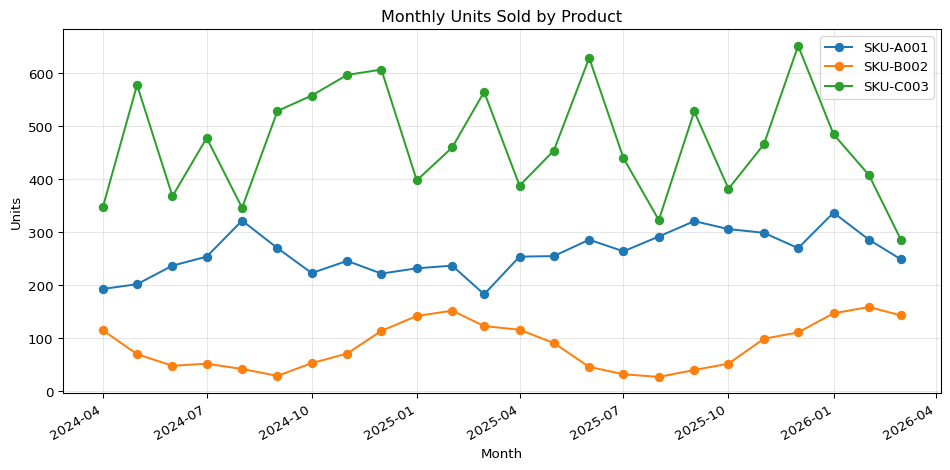

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for pid, g in df.groupby('product_id'):
    g = g.sort_values('date')
    ax.plot(g['date'], g['units_sold'], marker='o', label=pid)
ax.set_title('Monthly Units Sold by Product')
ax.set_xlabel('Month')
ax.set_ylabel('Units')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(DATA_DIR / 'trend_units.png', dpi=120)
plt.show()

## 3개월 이동평균

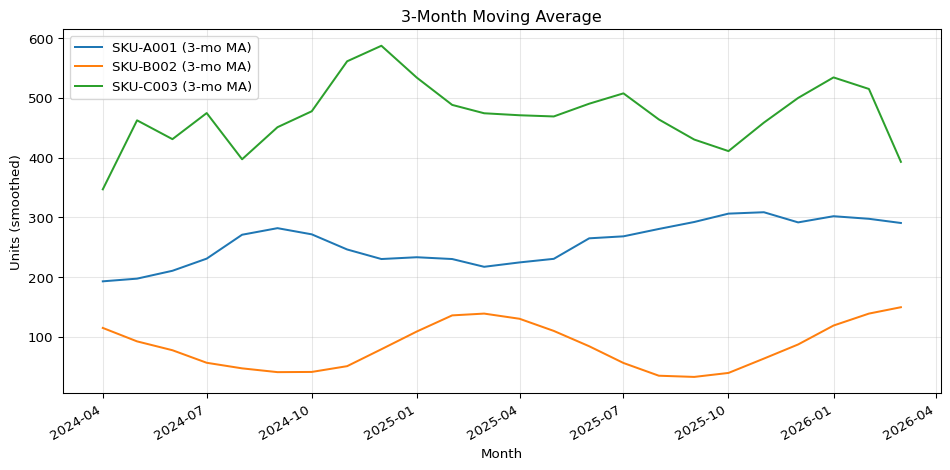

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for pid, g in df.groupby('product_id'):
    g = g.sort_values('date').reset_index(drop=True)
    g['ma3'] = g['units_sold'].rolling(window=3, min_periods=1).mean()
    ax.plot(g['date'], g['ma3'], label=f'{pid} (3-mo MA)')
ax.set_title('3-Month Moving Average')
ax.set_xlabel('Month')
ax.set_ylabel('Units (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(DATA_DIR / 'trend_ma3.png', dpi=120)
plt.show()

## 월별 계절성 (각 월의 평균)

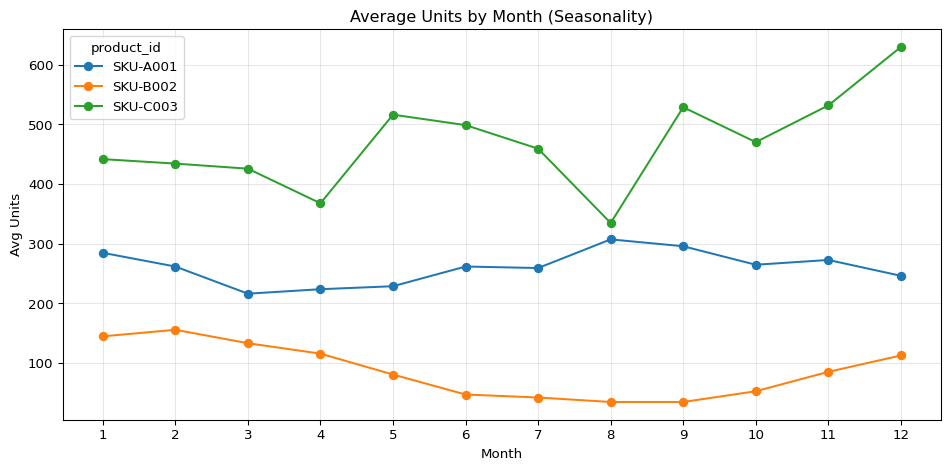

In [5]:
df['month'] = df['date'].dt.month
season = df.groupby(['product_id', 'month'])['units_sold'].mean().unstack(0)
fig, ax = plt.subplots(figsize=(10, 5))
season.plot(ax=ax, marker='o')
ax.set_title('Average Units by Month (Seasonality)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Units')
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(DATA_DIR / 'trend_seasonality.png', dpi=120)
plt.show()

## 요약 통계

In [6]:
summary = df.groupby('product_id').agg(
    months=('date', 'nunique'),
    avg_units=('units_sold', 'mean'),
    std_units=('units_sold', 'std'),
    total_revenue=('revenue', 'sum'),
    last_12m_avg=('units_sold', lambda s: s.tail(12).mean()),
).round(1)
summary

,months,avg_units,std_units,total_revenue,last_12m_avg
product_id,,,,,
SKU-A001,24,260.0,41.0,280800000,284.9
SKU-B002,24,86.4,44.3,580720000,88.6
SKU-C003,24,469.7,104.3,101448000,453.4


## 다음 단계

- 차트 PNG와 요약 표를 Claude Desktop에 붙여넣고 `data_diagnosis(si)`로 진단.
- 진단이 ✅이면 `03_forecast.ipynb`로 예측 진행.